In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from IPython.display import display
from tqdm.auto import tqdm

from tokenizer import DigitTokenizer
from data_stream import MultiplicationDataStream
from recurrent_modulo_transformer import (
    RecurrentModuloModel,
)

In [2]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

batch_size = 100

max_seq_len = 32
max_product_seq_len = 2 * max_seq_len

max_modulus = 20

d_model = 256
dropout = 0.1

learning_rate = 1e-4
weight_decay = 0.1

intermediate_loss_weight = 1.0

validation_interval = 100
validation_steps = 20
plot_interval = 10

use_bf16 = (
    device.type == "cuda"
    and torch.cuda.is_bf16_supported()
)

torch.set_float32_matmul_precision(
    "high"
)

print("Device:", device)
print("BF16:", use_bf16)

Device: cuda
BF16: True


In [3]:
tokenizer = DigitTokenizer()

data_stream = MultiplicationDataStream(
    tokenizer=tokenizer,
    batch_size=batch_size,
    max_seq_len=max_seq_len,
    initial_max=max_modulus,
    growth_rate=0.0,
    beta_alpha=2.0,
    beta_beta=5.0,
    rehearsal_fraction=0.0,
    rehearsal_max=max_modulus,
    seed=42,
)

pad_id = tokenizer.char_to_int[
    "<pad>"
]

In [4]:
model = RecurrentModuloModel(
    max_modulus=max_modulus,
    max_product_seq_len=max_product_seq_len,
    d_model=d_model,
    dropout=dropout,
).to(
    device
)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(
    f"Parameters: {parameter_count:,}"
)

Parameters: 626,708


In [5]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)

final_loss_function = nn.CrossEntropyLoss()

intermediate_loss_function = (
    nn.CrossEntropyLoss(
        ignore_index=-100
    )
)

In [6]:
def reversed_digits_to_integers(
    digits: torch.Tensor,
) -> torch.Tensor:
    batch_size, seq_len = digits.shape

    digit_mask = (
        (digits >= 0)
        & (digits <= 9)
    )

    numeric_digits = digits.masked_fill(
        ~digit_mask,
        0,
    )

    powers = (
        10
        ** torch.arange(
            seq_len,
            device=digits.device,
            dtype=torch.long,
        )
    )

    values = (
        numeric_digits
        * powers.unsqueeze(0)
    ).sum(
        dim=1
    )

    return values

In [7]:
def create_product_inputs(
    a: torch.Tensor,
    b: torch.Tensor,
) -> tuple[
    torch.Tensor,
    torch.Tensor,
]:
    a_values = reversed_digits_to_integers(
        a
    )

    b_values = reversed_digits_to_integers(
        b
    )

    product_values = (
        a_values
        * b_values
    )

    batch_size = a.shape[0]

    product_inputs = torch.full(
        (
            batch_size,
            max_product_seq_len,
        ),
        pad_id,
        dtype=torch.long,
        device=a.device,
    )

    for batch_index in range(
        batch_size
    ):
        product_digits = [
            int(digit)
            for digit in str(
                product_values[
                    batch_index
                ].item()
            )
        ]

        if (
            len(product_digits)
            > max_product_seq_len
        ):
            raise ValueError(
                "Product exceeds max_product_seq_len."
            )

        product_inputs[
            batch_index,
            :len(product_digits),
        ] = torch.tensor(
            product_digits,
            dtype=torch.long,
            device=a.device,
        )

    product_padding_mask = (
        product_inputs == pad_id
    )

    return (
        product_inputs,
        product_padding_mask,
    )

In [8]:
def create_modulus_values(
    p: torch.Tensor,
) -> torch.Tensor:
    modulus_values = (
        reversed_digits_to_integers(
            p
        )
    )

    if torch.any(
        modulus_values < 1
    ):
        raise ValueError(
            "Modulus must be at least 1."
        )

    if torch.any(
        modulus_values > max_modulus
    ):
        raise ValueError(
            f"Modulus exceeds max_modulus={max_modulus}."
        )

    return modulus_values

In [9]:
def create_remainder_targets(
    product_inputs: torch.Tensor,
    product_padding_mask: torch.Tensor,
    modulus_values: torch.Tensor,
) -> tuple[
    torch.Tensor,
    torch.Tensor,
]:
    batch_size = (
        product_inputs.shape[0]
    )

    final_targets = torch.zeros(
        batch_size,
        dtype=torch.long,
        device=product_inputs.device,
    )

    intermediate_targets = torch.full(
        (
            batch_size,
            max_product_seq_len,
        ),
        -100,
        dtype=torch.long,
        device=product_inputs.device,
    )

    remainders = torch.zeros(
        batch_size,
        dtype=torch.long,
        device=product_inputs.device,
    )

    for step in range(
        max_product_seq_len
    ):
        active_step = (
            ~product_padding_mask[
                :,
                step,
            ]
        )

        current_digits = product_inputs[
            :,
            step,
        ].masked_fill(
            ~active_step,
            0,
        )

        updated_remainders = (
            10 * remainders
            + current_digits
        ) % modulus_values

        remainders = torch.where(
            active_step,
            updated_remainders,
            remainders,
        )

        intermediate_targets[
            active_step,
            step,
        ] = remainders[
            active_step
        ]

    final_targets.copy_(
        remainders
    )

    return (
        final_targets,
        intermediate_targets,
    )

In [10]:
def compute_class_accuracy(
    logits: torch.Tensor,
    targets: torch.Tensor,
    ignore_index: int | None = None,
) -> tuple[int, int]:
    predictions = logits.argmax(
        dim=-1
    )

    if ignore_index is None:
        valid_positions = torch.ones_like(
            targets,
            dtype=torch.bool,
        )
    else:
        valid_positions = (
            targets != ignore_index
        )

    correct_count = (
        (
            predictions == targets
        )
        & valid_positions
    ).sum().item()

    valid_count = (
        valid_positions.sum().item()
    )

    return (
        correct_count,
        valid_count,
    )

In [11]:
sample_batch = data_stream.next_batch().to(
    device
)

sample_a, sample_b, sample_p, _ = (
    sample_batch.unbind(
        dim=1
    )
)

(
    sample_product_inputs,
    sample_product_padding_mask,
) = create_product_inputs(
    sample_a,
    sample_b,
)

sample_modulus_values = (
    create_modulus_values(
        sample_p
    )
)

(
    sample_final_targets,
    sample_intermediate_targets,
) = create_remainder_targets(
    sample_product_inputs,
    sample_product_padding_mask,
    sample_modulus_values,
)

sample_a_values = (
    reversed_digits_to_integers(
        sample_a
    )
)

sample_b_values = (
    reversed_digits_to_integers(
        sample_b
    )
)

for index in range(5):
    product_digits = (
        sample_product_inputs[
            index
        ][
            ~sample_product_padding_mask[
                index
            ]
        ].tolist()
    )

    intermediate_targets = (
        sample_intermediate_targets[
            index
        ]
    )

    intermediate_targets = (
        intermediate_targets[
            intermediate_targets != -100
        ].tolist()
    )

    a_value = sample_a_values[
        index
    ].item()

    b_value = sample_b_values[
        index
    ].item()

    modulus = sample_modulus_values[
        index
    ].item()

    print(
        f"{a_value} × {b_value} = {a_value * b_value}"
    )

    print(
        "modulus:",
        modulus,
    )

    print(
        "product digits:",
        product_digits,
    )

    print(
        "intermediate remainders:",
        intermediate_targets,
    )

    print(
        "final target:",
        sample_final_targets[
            index
        ].item(),
    )

    print(
        "expected:",
        (
            a_value
            * b_value
        ) % modulus,
    )

    print()

7 × 13 = 91
modulus: 4
product digits: [9, 1]
intermediate remainders: [1, 3]
final target: 3
expected: 3

51 × 68 = 3468
modulus: 19
product digits: [3, 4, 6, 8]
intermediate remainders: [3, 15, 4, 10]
final target: 10
expected: 10

19 × 22 = 418
modulus: 12
product digits: [4, 1, 8]
intermediate remainders: [4, 5, 10]
final target: 10
expected: 10

3 × 5 = 15
modulus: 7
product digits: [1, 5]
intermediate remainders: [1, 1]
final target: 1
expected: 1

65 × 57 = 3705
modulus: 20
product digits: [3, 7, 0, 5]
intermediate remainders: [3, 17, 10, 5]
final target: 5
expected: 5



In [12]:
@torch.no_grad()
def validate_model() -> dict[str, float]:
    model.eval()

    validation_loader = (
        data_stream.create_validation_chunk_loader(
            num_steps=validation_steps,
            lookahead_steps=0,
            batch_size=batch_size,
            seed=10_000,
        )
    )

    total_loss_sum = 0.0
    final_loss_sum = 0.0
    intermediate_loss_sum = 0.0

    final_correct = 0
    final_count = 0

    intermediate_correct = 0
    intermediate_count = 0

    total_batches = 0

    for batch in validation_loader:
        batch = batch.to(
            device
        )

        a, b, p, _ = batch.unbind(
            dim=1
        )

        (
            product_inputs,
            product_padding_mask,
        ) = create_product_inputs(
            a,
            b,
        )

        modulus_values = (
            create_modulus_values(
                p
            )
        )

        (
            final_targets,
            intermediate_targets,
        ) = create_remainder_targets(
            product_inputs,
            product_padding_mask,
            modulus_values,
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=use_bf16,
        ):
            (
                final_logits,
                intermediate_logits,
            ) = model(
                product_inputs,
                product_padding_mask,
                modulus_values,
            )

            final_loss = (
                final_loss_function(
                    final_logits,
                    final_targets,
                )
            )

            intermediate_loss = (
                intermediate_loss_function(
                    intermediate_logits.reshape(
                        -1,
                        model.remainder_class_count,
                    ),
                    intermediate_targets.reshape(
                        -1
                    ),
                )
            )

            total_loss = (
                final_loss
                + intermediate_loss_weight
                * intermediate_loss
            )

        (
            batch_final_correct,
            batch_final_count,
        ) = compute_class_accuracy(
            final_logits,
            final_targets,
        )

        (
            batch_intermediate_correct,
            batch_intermediate_count,
        ) = compute_class_accuracy(
            intermediate_logits,
            intermediate_targets,
            ignore_index=-100,
        )

        final_correct += (
            batch_final_correct
        )

        final_count += (
            batch_final_count
        )

        intermediate_correct += (
            batch_intermediate_correct
        )

        intermediate_count += (
            batch_intermediate_count
        )

        total_loss_sum += (
            total_loss.item()
        )

        final_loss_sum += (
            final_loss.item()
        )

        intermediate_loss_sum += (
            intermediate_loss.item()
        )

        total_batches += 1

    return {
        "total_loss": (
            total_loss_sum
            / total_batches
        ),
        "final_loss": (
            final_loss_sum
            / total_batches
        ),
        "intermediate_loss": (
            intermediate_loss_sum
            / total_batches
        ),
        "final_accuracy": (
            final_correct
            / final_count
        ),
        "intermediate_accuracy": (
            intermediate_correct
            / intermediate_count
        ),
    }

In [13]:
global_step = 0

train_step_history = []

train_total_loss_history = []
train_final_loss_history = []
train_intermediate_loss_history = []

train_final_accuracy_history = []
train_intermediate_accuracy_history = []

validation_step_history = []

validation_total_loss_history = []
validation_final_loss_history = []
validation_intermediate_loss_history = []

validation_final_accuracy_history = []
validation_intermediate_accuracy_history = []

In [14]:
def train_model(
    steps: int,
) -> None:
    global global_step

    figure, axes = plt.subplots(
        3,
        1,
        figsize=(14, 14),
        sharex=True,
    )

    total_loss_axis = axes[0]
    component_loss_axis = axes[1]
    accuracy_axis = axes[2]

    display_handle = display(
        figure,
        display_id=True,
    )

    def update_live_plot() -> None:
        total_loss_axis.clear()
        component_loss_axis.clear()
        accuracy_axis.clear()

        total_loss_axis.plot(
            train_step_history,
            train_total_loss_history,
            label="Training total loss",
            linewidth=2,
        )

        if validation_total_loss_history:
            total_loss_axis.plot(
                validation_step_history,
                validation_total_loss_history,
                label="Validation total loss",
                linewidth=2,
                marker="o",
            )

        component_loss_axis.plot(
            train_step_history,
            train_final_loss_history,
            label="Training final loss",
            linewidth=2,
        )

        component_loss_axis.plot(
            train_step_history,
            train_intermediate_loss_history,
            label="Training intermediate loss",
            linewidth=2,
        )

        if validation_final_loss_history:
            component_loss_axis.plot(
                validation_step_history,
                validation_final_loss_history,
                label="Validation final loss",
                linewidth=2,
                marker="o",
            )

            component_loss_axis.plot(
                validation_step_history,
                validation_intermediate_loss_history,
                label="Validation intermediate loss",
                linewidth=2,
                marker="o",
            )

        accuracy_axis.plot(
            train_step_history,
            train_final_accuracy_history,
            label="Training final accuracy",
            linewidth=2,
        )

        accuracy_axis.plot(
            train_step_history,
            train_intermediate_accuracy_history,
            label="Training intermediate accuracy",
            linewidth=2,
        )

        if validation_final_accuracy_history:
            accuracy_axis.plot(
                validation_step_history,
                validation_final_accuracy_history,
                label="Validation final accuracy",
                linewidth=2,
                marker="o",
            )

            accuracy_axis.plot(
                validation_step_history,
                validation_intermediate_accuracy_history,
                label="Validation intermediate accuracy",
                linewidth=2,
                marker="o",
            )

        total_loss_axis.set_title(
            "Explicit Remainder-Class Modulo Model"
        )

        total_loss_axis.set_ylabel(
            "Total loss"
        )

        component_loss_axis.set_ylabel(
            "Component loss"
        )

        accuracy_axis.set_xlabel(
            "Training step"
        )

        accuracy_axis.set_ylabel(
            "Accuracy"
        )

        accuracy_axis.set_ylim(
            0.0,
            1.0,
        )

        total_loss_axis.legend(
            loc="upper right"
        )

        component_loss_axis.legend(
            loc="upper right"
        )

        accuracy_axis.legend(
            loc="lower right"
        )

        total_loss_axis.grid(
            alpha=0.3
        )

        component_loss_axis.grid(
            alpha=0.3
        )

        accuracy_axis.grid(
            alpha=0.3
        )

        figure.tight_layout()

        display_handle.update(
            figure
        )

    progress_bar = tqdm(
        range(steps),
        desc="Training remainder classes",
    )

    for _ in progress_bar:
        model.train()

        batch = data_stream.next_batch().to(
            device
        )

        a, b, p, _ = batch.unbind(
            dim=1
        )

        (
            product_inputs,
            product_padding_mask,
        ) = create_product_inputs(
            a,
            b,
        )

        modulus_values = (
            create_modulus_values(
                p
            )
        )

        (
            final_targets,
            intermediate_targets,
        ) = create_remainder_targets(
            product_inputs,
            product_padding_mask,
            modulus_values,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=use_bf16,
        ):
            (
                final_logits,
                intermediate_logits,
            ) = model(
                product_inputs,
                product_padding_mask,
                modulus_values,
            )

            final_loss = (
                final_loss_function(
                    final_logits,
                    final_targets,
                )
            )

            intermediate_loss = (
                intermediate_loss_function(
                    intermediate_logits.reshape(
                        -1,
                        model.remainder_class_count,
                    ),
                    intermediate_targets.reshape(
                        -1
                    ),
                )
            )

            total_loss = (
                final_loss
                + intermediate_loss_weight
                * intermediate_loss
            )

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()

        with torch.no_grad():
            (
                final_correct,
                final_count,
            ) = compute_class_accuracy(
                final_logits,
                final_targets,
            )

            (
                intermediate_correct,
                intermediate_count,
            ) = compute_class_accuracy(
                intermediate_logits,
                intermediate_targets,
                ignore_index=-100,
            )

            final_accuracy = (
                final_correct
                / final_count
            )

            intermediate_accuracy = (
                intermediate_correct
                / intermediate_count
            )

        global_step += 1

        train_step_history.append(
            global_step
        )

        train_total_loss_history.append(
            total_loss.item()
        )

        train_final_loss_history.append(
            final_loss.item()
        )

        train_intermediate_loss_history.append(
            intermediate_loss.item()
        )

        train_final_accuracy_history.append(
            final_accuracy
        )

        train_intermediate_accuracy_history.append(
            intermediate_accuracy
        )

        if (
            global_step
            % validation_interval
            == 0
        ):
            validation_results = (
                validate_model()
            )

            validation_step_history.append(
                global_step
            )

            validation_total_loss_history.append(
                validation_results[
                    "total_loss"
                ]
            )

            validation_final_loss_history.append(
                validation_results[
                    "final_loss"
                ]
            )

            validation_intermediate_loss_history.append(
                validation_results[
                    "intermediate_loss"
                ]
            )

            validation_final_accuracy_history.append(
                validation_results[
                    "final_accuracy"
                ]
            )

            validation_intermediate_accuracy_history.append(
                validation_results[
                    "intermediate_accuracy"
                ]
            )

        if (
            global_step
            % plot_interval
            == 0
        ):
            update_live_plot()

        progress_values = {
            "step": global_step,
            "total_loss": (
                f"{total_loss.item():.4f}"
            ),
            "final_loss": (
                f"{final_loss.item():.4f}"
            ),
            "intermediate_loss": (
                f"{intermediate_loss.item():.4f}"
            ),
            "final_acc": (
                f"{final_accuracy:.4f}"
            ),
            "intermediate_acc": (
                f"{intermediate_accuracy:.4f}"
            ),
        }

        if validation_final_accuracy_history:
            progress_values[
                "val_final_acc"
            ] = (
                f"{validation_final_accuracy_history[-1]:.4f}"
            )

            progress_values[
                "val_intermediate_acc"
            ] = (
                f"{validation_intermediate_accuracy_history[-1]:.4f}"
            )

        progress_bar.set_postfix(
            progress_values
        )

    update_live_plot()

    plt.close(
        figure
    )

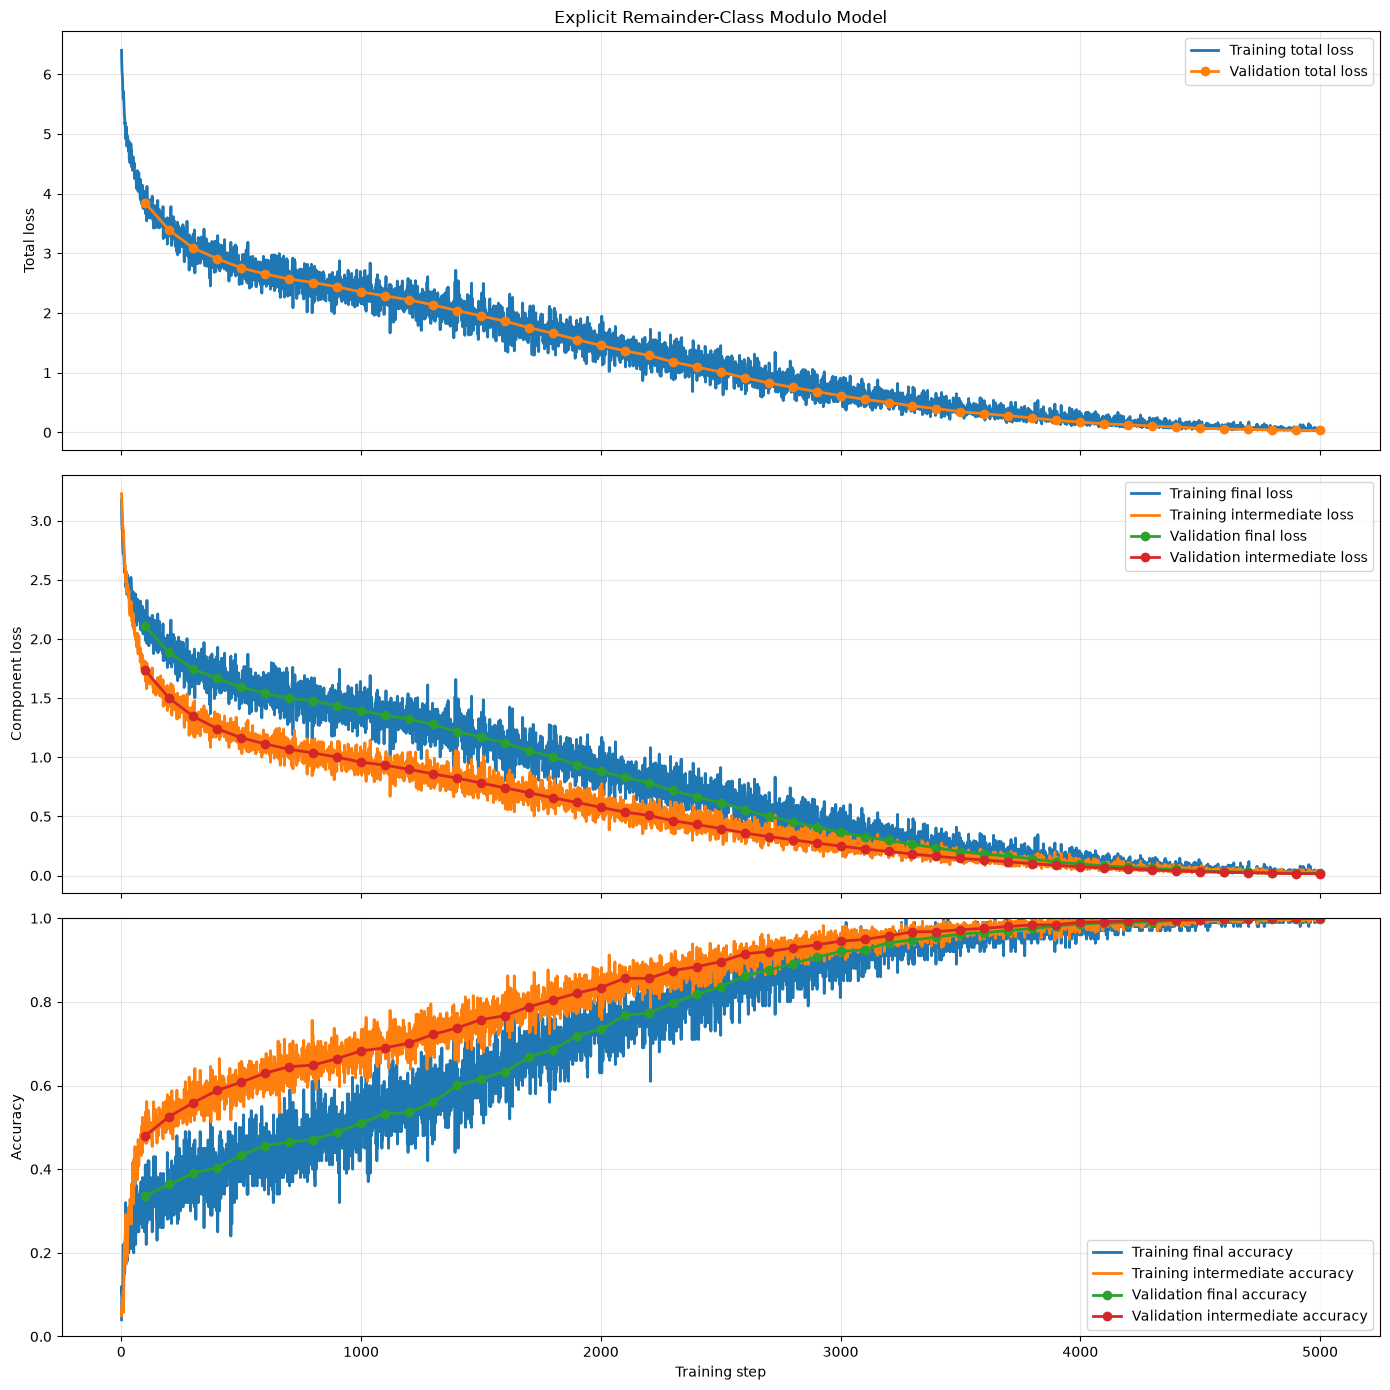

Training remainder classes:   0%|          | 0/3000 [00:00<?, ?it/s]

In [17]:
train_model(
    steps=3_000,
)